# Patient-Aware 25-Epoch LiTS Baseline

This is the first controlled longer baseline after the verified loader,
16-slice overfit test, five-epoch smoke test, and validation-volume forensic
review.

It starts a **new** MobileNetV2-U-Net model and selects checkpoints using mean
Dice across tumor-positive validation patients. This prevents a high-burden
patient such as volume 108 from dominating the decision.

The test split remains locked throughout.

## tl;dr

Run all cells with the project GPU kernel. Training may pause after an epoch if
the GPU reaches the thermal boundary. Let the GPU cool and rerun the training
cell; optimizer, scheduler, scaler, sampling generator, history, and random
states are restored.

Primary checkpoint metric: **mean tumor-positive patient micro-Dice at 0.50**.

Secondary safeguards:

- global micro-Dice;
- median and worst patient Dice;
- volumes 104 and 116;
- positive slices predicted empty;
- false positives on empty slices and tumor-negative patients;
- lesion-size quartiles;
- validation threshold sensitivity.

## Context & Methods

### Key assumptions

- Corrected LiTS v2 and its frozen manifest are the source of truth.
- `rot180` is the documented correction for the known RAS/LPS header mismatch.
- Augmentation is applied only to training image/mask pairs.
- Validation is deterministic and unaugmented.
- Patient-level checkpoint selection uses only tumor-positive validation
  patients; tumor-negative patients are reported as a false-positive guardrail.
- Threshold 0.50 is the official primary result.
- This notebook does not evaluate the held-out test split.

In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import math
import platform
import random
import subprocess
import sys
import time
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
SMOKE_PER_SLICE = (
    PROJECT_ROOT / "Practice" / "manifest_baseline_smoke_outputs"
    / "baseline_smoke_per_slice.csv"
)
OUTPUT_DIR = PROJECT_ROOT / "Practice" / "patient_aware_baseline_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
RUN_TRAINING = True
RESUME_IF_AVAILABLE = True
EPOCHS = 25
MIN_EPOCHS_BEFORE_EARLY_STOP = 10
EARLY_STOPPING_PATIENCE = 6
EARLY_STOPPING_MIN_DELTA = 0.001
BATCH_SIZE = 8
VALIDATION_BATCH_SIZE = 16
LEARNING_RATE = 3e-4
MIN_LEARNING_RATE = 3e-6
WEIGHT_DECAY = 1e-4
POSITIVE_SAMPLE_WEIGHT = 3.0
FIXED_THRESHOLD = 0.50
THRESHOLDS = np.arange(0.30, 0.71, 0.05).round(2)
USE_MIXED_PRECISION = True
USE_PRETRAINED_ENCODER = False
NUM_WORKERS = 0
MAX_GPU_TEMP_C = 86
EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__}")
print(f"OS: {platform.platform()} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Outputs: {OUTPUT_DIR}")

Python 3.11.15 | PyTorch 2.6.0+cu124
OS: Windows-10-10.0.26200-SP0 | CUDA: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\patient_aware_baseline_outputs


## Data

### 1. Verify frozen data and lock the test split

In [2]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


manifest_hash = sha256_file(MANIFEST_PATH)
assert manifest_hash == EXPECTED_MANIFEST_SHA256
manifest = pd.read_csv(MANIFEST_PATH)
assert len(manifest) == 58_638
assert manifest["sample_id"].is_unique
assert manifest["verification_status"].eq("verified").all()
assert manifest["manual_spatial_status"].eq("approved").all()

try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError as exc:
    print(f"PASS: test split locked: {exc}")
else:
    raise AssertionError("Test split opened without explicit authorization.")

volume_sets = {
    split: set(manifest.loc[manifest["split"].eq(split), "volume_id"])
    for split in ("train", "val", "test")
}
assert volume_sets["train"].isdisjoint(volume_sets["val"])
assert volume_sets["train"].isdisjoint(volume_sets["test"])
assert volume_sets["val"].isdisjoint(volume_sets["test"])
print(f"PASS: frozen manifest {manifest_hash[:12]}... and patient isolation verified.")

PASS: test split locked: Test data access is locked. Pass allow_test=True only for the one-time held-out evaluation after model decisions are frozen.
PASS: frozen manifest 575a6fc391d6... and patient isolation verified.


### 2. Define paired training augmentation

The transform uses bilinear interpolation for images and nearest-neighbour interpolation for masks. Validation receives no transform.

In [3]:
class PairedTrainingAugment:
    def __init__(
        self,
        flip_probability=0.30,
        affine_probability=0.60,
        max_rotation_degrees=10.0,
        max_translation_fraction=0.05,
        scale_range=(0.95, 1.05),
        intensity_probability=0.50,
        brightness_shift=0.05,
        contrast_range=(0.90, 1.10),
    ):
        self.flip_probability = flip_probability
        self.affine_probability = affine_probability
        self.max_rotation_degrees = max_rotation_degrees
        self.max_translation_fraction = max_translation_fraction
        self.scale_range = scale_range
        self.intensity_probability = intensity_probability
        self.brightness_shift = brightness_shift
        self.contrast_range = contrast_range

    def __call__(self, image: np.ndarray, mask: np.ndarray):
        image = np.asarray(image, dtype=np.float32)
        mask = np.asarray(mask, dtype=np.float32)

        if random.random() < self.flip_probability:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()

        if random.random() < self.affine_probability:
            height, width = image.shape
            angle = random.uniform(-self.max_rotation_degrees, self.max_rotation_degrees)
            scale = random.uniform(*self.scale_range)
            tx = random.uniform(-self.max_translation_fraction, self.max_translation_fraction) * width
            ty = random.uniform(-self.max_translation_fraction, self.max_translation_fraction) * height
            matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, scale)
            matrix[:, 2] += (tx, ty)
            image = cv2.warpAffine(
                image, matrix, (width, height), flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_CONSTANT, borderValue=0,
            )
            mask = cv2.warpAffine(
                mask, matrix, (width, height), flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_CONSTANT, borderValue=0,
            )

        if random.random() < self.intensity_probability:
            contrast = random.uniform(*self.contrast_range)
            brightness = random.uniform(-self.brightness_shift, self.brightness_shift)
            image = np.clip(image * contrast + brightness, 0.0, 1.0)

        mask = (mask > 0.5).astype(np.float32)
        return np.ascontiguousarray(image), np.ascontiguousarray(mask)


train_transform = PairedTrainingAugment()

### 3. Build weighted training and natural validation loaders

In [4]:
train_dataset = VerifiedManifestDataset(
    MANIFEST_PATH, split="train", root_dir=DATASET_ROOT,
    target="tumor", transform=train_transform, validate_paths=True,
)
val_dataset = VerifiedManifestDataset(
    MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
    target="tumor", transform=None, validate_paths=True,
)

train_flags = np.asarray(train_dataset.tumor_positive_flags, dtype=bool)
weights = np.where(train_flags, POSITIVE_SAMPLE_WEIGHT, 1.0)
sampler_generator = torch.Generator().manual_seed(SEED)
train_sampler = WeightedRandomSampler(
    torch.as_tensor(weights, dtype=torch.double),
    num_samples=len(train_dataset), replacement=True,
    generator=sampler_generator,
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset, batch_size=VALIDATION_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)

natural_rate = float(train_flags.mean())
expected_rate = (
    POSITIVE_SAMPLE_WEIGHT * natural_rate
    / (POSITIVE_SAMPLE_WEIGHT * natural_rate + 1 - natural_rate)
)
preview_indices = list(iter(train_sampler))[:4096]
preview_rate = float(train_flags[preview_indices].mean())
sampling_audit = pd.DataFrame({
    "measure": ["Natural training", "Expected weighted", "Sampler preview"],
    "positive_slice_pct": [100 * natural_rate, 100 * expected_rate, 100 * preview_rate],
})
display(sampling_audit.style.format({"positive_slice_pct": "{:.2f}%"}))
print(f"Train={len(train_dataset):,} | Validation={len(val_dataset):,}")

,measure,positive_slice_pct
0,Natural training,12.12%
1,Expected weighted,29.27%
2,Sampler preview,29.42%


Train=40,667 | Validation=10,685


### 4. Preview augmentation integrity

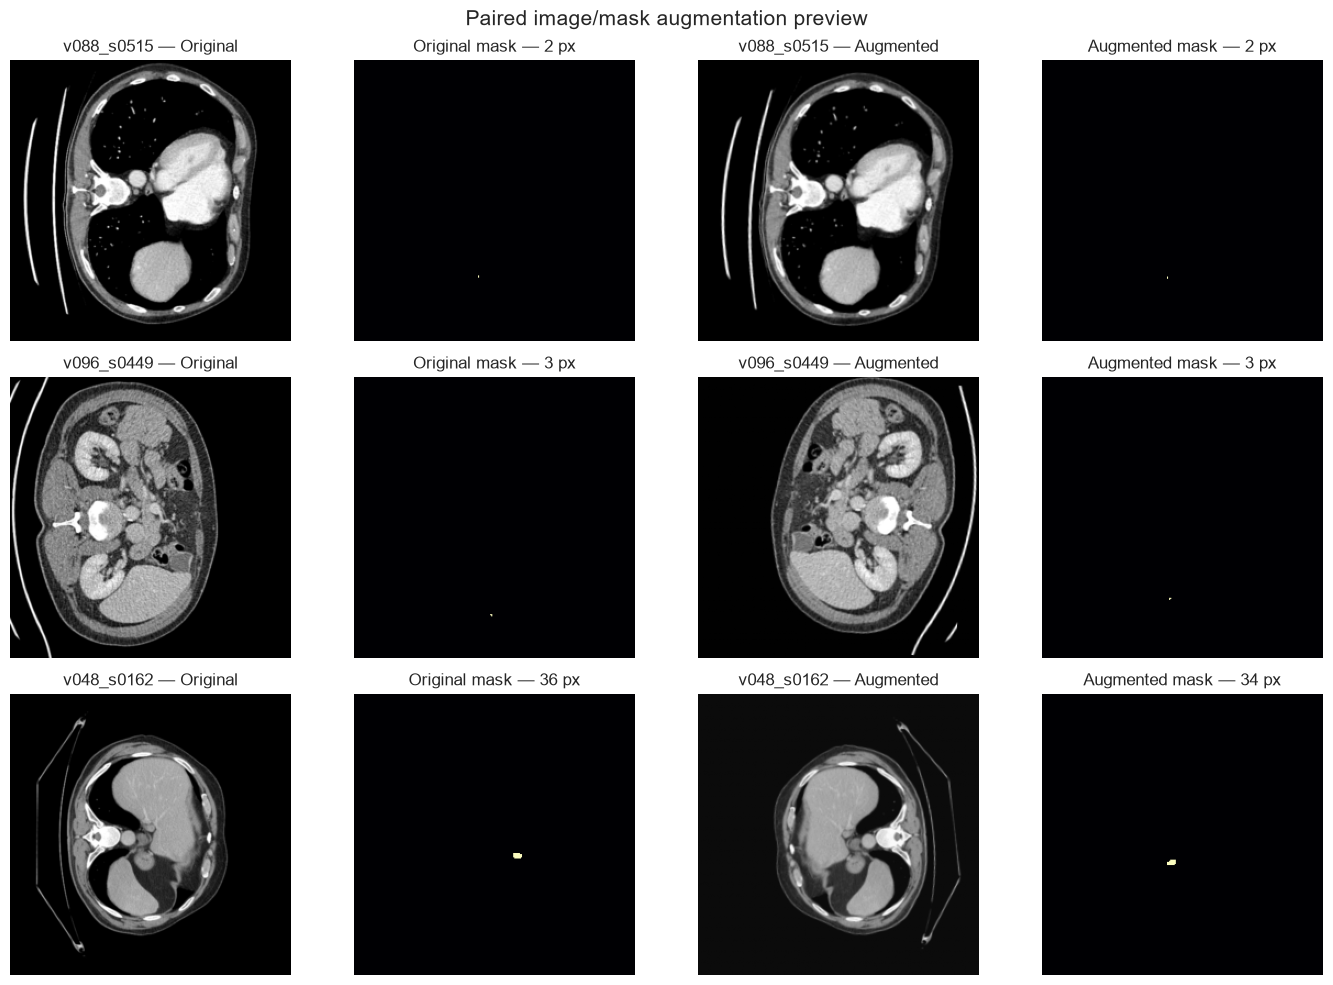

In [5]:
positive_indices = np.flatnonzero(train_flags)
preview_source_indices = np.random.default_rng(SEED).choice(
    positive_indices, size=6, replace=False
)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for row_index, dataset_index in enumerate(preview_source_indices[:3]):
    raw_dataset = VerifiedManifestDataset(
        MANIFEST_PATH, split="train", root_dir=DATASET_ROOT,
        target="tumor", sample_ids=[train_dataset.sample_ids[int(dataset_index)]],
        transform=None,
    )
    original = raw_dataset[0]
    original_image = original["image"][0].numpy()
    original_mask = original["mask"][0].numpy()
    augmented_image, augmented_mask = train_transform(original_image, original_mask)
    for column, (image, mask, title) in enumerate([
        (original_image, original_mask, "Original"),
        (augmented_image, augmented_mask, "Augmented"),
    ]):
        axis = axes[row_index, column * 2]
        axis.imshow(image, cmap="gray", vmin=0, vmax=1)
        axis.set_title(f"{original['sample_id']} — {title}")
        axis.axis("off")
        mask_axis = axes[row_index, column * 2 + 1]
        mask_axis.imshow(mask, cmap="magma", vmin=0, vmax=1)
        mask_axis.set_title(f"{title} mask — {int(mask.sum()):,} px")
        mask_axis.axis("off")
        assert set(np.unique(mask)).issubset({0.0, 1.0})
fig.suptitle("Paired image/mask augmentation preview", fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "augmentation_preview.png", dpi=160, bbox_inches="tight")
plt.show()

## Results

### 5. Define patient-aware evaluation and exact-resume utilities

In [6]:
from src.framework.losses.focal_dice import FocalDiceLoss
from src.framework.models.mobilenetv2_unet import MobileNetV2UNet


def gpu_stats():
    if not torch.cuda.is_available():
        return {"temperature_c": np.nan, "utilization_pct": np.nan, "memory_mb": np.nan}
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=temperature.gpu,utilization.gpu,memory.used",
             "--format=csv,noheader,nounits"],
            capture_output=True, text=True, check=True,
        )
        values = [float(value.strip()) for value in result.stdout.splitlines()[0].split(",")]
        return {"temperature_c": values[0], "utilization_pct": values[1], "memory_mb": values[2]}
    except Exception:
        return {"temperature_c": np.nan, "utilization_pct": np.nan, "memory_mb": np.nan}


def evaluate_patient_aware(model, loader, criterion, device, threshold=0.5, collect_rows=False):
    model.eval()
    loss_sum = intersection = predicted = actual = 0.0
    positive_seen = positive_detected = positive_empty = 0
    empty_seen = empty_with_fp = 0
    patient = {}
    rows = []
    with torch.inference_mode():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)
            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions = probabilities >= threshold
            truth = masks >= 0.5
            loss_sum += float(criterion(logits, masks)) * images.shape[0]
            intersection += float((predictions & truth).sum())
            predicted += float(predictions.sum())
            actual += float(truth.sum())

            for index, sample_id in enumerate(batch["sample_id"]):
                volume_id = int(batch["volume_id"][index])
                true_px = int(truth[index].sum())
                pred_px = int(predictions[index].sum())
                inter_px = int((predictions[index] & truth[index]).sum())
                dice = (2 * inter_px + 1e-6) / (pred_px + true_px + 1e-6)
                accumulator = patient.setdefault(
                    volume_id, {"intersection": 0, "predicted": 0, "true": 0,
                                "positive_slices": 0, "detected": 0, "positive_empty": 0,
                                "empty_slices": 0, "empty_with_fp": 0}
                )
                accumulator["intersection"] += inter_px
                accumulator["predicted"] += pred_px
                accumulator["true"] += true_px
                if true_px > 0:
                    positive_seen += 1
                    positive_detected += int(inter_px > 0)
                    positive_empty += int(pred_px == 0)
                    accumulator["positive_slices"] += 1
                    accumulator["detected"] += int(inter_px > 0)
                    accumulator["positive_empty"] += int(pred_px == 0)
                else:
                    empty_seen += 1
                    empty_with_fp += int(pred_px > 0)
                    accumulator["empty_slices"] += 1
                    accumulator["empty_with_fp"] += int(pred_px > 0)
                if collect_rows:
                    rows.append({
                        "sample_id": sample_id, "volume_id": volume_id,
                        "slice_index": int(batch["slice_index"][index]),
                        "true_pixels": true_px, "predicted_pixels": pred_px,
                        "intersection_pixels": inter_px, "dice": dice,
                        "mean_probability": float(probabilities[index].mean()),
                        "max_probability": float(probabilities[index].max()),
                    })

    patient_rows = []
    for volume_id, values in sorted(patient.items()):
        denominator = values["predicted"] + values["true"]
        patient_rows.append({
            "volume_id": volume_id,
            "micro_dice": (
                (2 * values["intersection"] + 1e-6) / (denominator + 1e-6)
            ),
            "true_pixels": values["true"],
            "predicted_pixels": values["predicted"],
            "positive_slices": values["positive_slices"],
            "positive_slice_recall": values["detected"] / max(values["positive_slices"], 1),
            "positive_predicted_empty_pct": 100 * values["positive_empty"] / max(values["positive_slices"], 1),
            "empty_slice_false_positive_pct": 100 * values["empty_with_fp"] / max(values["empty_slices"], 1),
        })
    patient_frame = pd.DataFrame(patient_rows)
    tumor_positive_patients = patient_frame.loc[patient_frame["true_pixels"].gt(0)]
    return {
        "loss": loss_sum / len(loader.dataset),
        "global_micro_dice": float((2 * intersection + 1e-6) / (predicted + actual + 1e-6)),
        "pixel_precision": float((intersection + 1e-6) / (predicted + 1e-6)),
        "pixel_recall": float((intersection + 1e-6) / (actual + 1e-6)),
        "positive_slice_recall": positive_detected / max(positive_seen, 1),
        "positive_predicted_empty_pct": 100 * positive_empty / max(positive_seen, 1),
        "empty_slice_false_positive_pct": 100 * empty_with_fp / max(empty_seen, 1),
        "mean_patient_dice": float(tumor_positive_patients["micro_dice"].mean()),
        "median_patient_dice": float(tumor_positive_patients["micro_dice"].median()),
        "worst_patient_dice": float(tumor_positive_patients["micro_dice"].min()),
        "predicted_pixels": int(predicted), "true_pixels": int(actual),
        "patient_rows": patient_rows, "rows": rows,
    }


def capture_rng_state():
    return {
        "python_random_state": random.getstate(),
        "numpy_random_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state_all": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "sampler_generator_state": sampler_generator.get_state(),
    }


def restore_rng_state(payload):
    random.setstate(payload["python_random_state"])
    np.random.set_state(payload["numpy_random_state"])
    torch.set_rng_state(payload["torch_rng_state"].detach().cpu().to(torch.uint8))
    if torch.cuda.is_available() and payload.get("cuda_rng_state_all") is not None:
        torch.cuda.set_rng_state_all([
            state.detach().cpu().to(torch.uint8)
            for state in payload["cuda_rng_state_all"]
        ])
    sampler_generator.set_state(
        payload["sampler_generator_state"].detach().cpu().to(torch.uint8)
    )


def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, history, patient_history, best_score, stale_epochs):
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "epoch": int(epoch), "history": history,
        "patient_history": patient_history,
        "best_mean_patient_dice": float(best_score),
        "stale_epochs": int(stale_epochs),
        "rng_state": capture_rng_state(),
        "manifest_sha256": manifest_hash,
        "configuration": {
            "epochs": EPOCHS, "learning_rate": LEARNING_RATE,
            "positive_sample_weight": POSITIVE_SAMPLE_WEIGHT,
            "fixed_threshold": FIXED_THRESHOLD,
        },
    }, path)

### 6. Train, validate, checkpoint, cool, and resume

The cell pauses when temperature is at or above the limit. Rerun this cell after cooling.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_enabled = bool(USE_MIXED_PRECISION and device.type == "cuda")
model = MobileNetV2UNet(
    in_channels=1, out_channels=1, pretrained=USE_PRETRAINED_ENCODER
).to(device)
criterion = FocalDiceLoss(
    focal_alpha=0.75, focal_gamma=2.0, focal_weight=0.5, dice_weight=0.5
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=MIN_LEARNING_RATE
)
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

last_checkpoint = OUTPUT_DIR / "patient_aware_last.pth"
best_checkpoint = OUTPUT_DIR / "patient_aware_best.pth"
history, patient_history = [], []
start_epoch, stale_epochs = 1, 0
best_mean_patient_dice = -1.0

if RESUME_IF_AVAILABLE and last_checkpoint.is_file():
    checkpoint = torch.load(last_checkpoint, map_location=device, weights_only=False)
    if checkpoint.get("manifest_sha256") != manifest_hash:
        raise RuntimeError("Checkpoint manifest differs from the frozen dataset.")
    expected_configuration = {
        "epochs": EPOCHS, "learning_rate": LEARNING_RATE,
        "positive_sample_weight": POSITIVE_SAMPLE_WEIGHT,
        "fixed_threshold": FIXED_THRESHOLD,
    }
    if checkpoint.get("configuration") != expected_configuration:
        raise RuntimeError(
            "Existing checkpoint configuration differs from this notebook. "
            "Use a new output directory for a changed experiment."
        )
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    scaler.load_state_dict(checkpoint.get("scaler_state", {}))
    history = list(checkpoint.get("history", []))
    patient_history = list(checkpoint.get("patient_history", []))
    best_mean_patient_dice = float(checkpoint.get("best_mean_patient_dice", -1))
    stale_epochs = int(checkpoint.get("stale_epochs", 0))
    start_epoch = int(checkpoint["epoch"]) + 1
    restore_rng_state(checkpoint["rng_state"])
    print(f"Resuming exactly at epoch {start_epoch}; best patient Dice={best_mean_patient_dice:.4f}.")

stop_reason = "not_started"
if RUN_TRAINING and start_epoch <= EPOCHS:
    started = time.perf_counter()
    try:
        for epoch in range(start_epoch, EPOCHS + 1):
            model.train()
            train_loss_sum = 0.0
            for batch in train_loader:
                images = batch["image"].to(device, non_blocking=True)
                masks = batch["mask"].to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=amp_enabled):
                    logits = model(images)
                    loss = criterion(logits, masks)
                if not torch.isfinite(loss):
                    raise FloatingPointError(f"Non-finite loss at epoch {epoch}.")
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()
                train_loss_sum += float(loss.detach()) * images.shape[0]

            validation = evaluate_patient_aware(
                model, val_loader, criterion, device, FIXED_THRESHOLD
            )
            thermal = gpu_stats()
            record = {
                "epoch": epoch,
                "train_loss": train_loss_sum / len(train_dataset),
                "val_loss": validation["loss"],
                "val_global_micro_dice": validation["global_micro_dice"],
                "val_mean_patient_dice": validation["mean_patient_dice"],
                "val_median_patient_dice": validation["median_patient_dice"],
                "val_worst_patient_dice": validation["worst_patient_dice"],
                "val_pixel_precision": validation["pixel_precision"],
                "val_pixel_recall": validation["pixel_recall"],
                "val_positive_slice_recall": validation["positive_slice_recall"],
                "val_positive_predicted_empty_pct": validation["positive_predicted_empty_pct"],
                "val_empty_slice_false_positive_pct": validation["empty_slice_false_positive_pct"],
                "lr": optimizer.param_groups[0]["lr"], **thermal,
                "elapsed_seconds": time.perf_counter() - started,
            }
            history.append(record)
            for patient_row in validation["patient_rows"]:
                patient_history.append({"epoch": epoch, **patient_row})

            improved = validation["mean_patient_dice"] > (
                best_mean_patient_dice + EARLY_STOPPING_MIN_DELTA
            )
            if improved:
                best_mean_patient_dice = validation["mean_patient_dice"]
                stale_epochs = 0
            else:
                stale_epochs += 1
            scheduler.step()

            pd.DataFrame(history).to_csv(OUTPUT_DIR / "patient_aware_history.csv", index=False)
            pd.DataFrame(patient_history).to_csv(OUTPUT_DIR / "patient_metrics_by_epoch.csv", index=False)
            save_checkpoint(
                last_checkpoint, model, optimizer, scheduler, scaler, epoch,
                history, patient_history, best_mean_patient_dice, stale_epochs,
            )
            if improved:
                save_checkpoint(
                    best_checkpoint, model, optimizer, scheduler, scaler, epoch,
                    history, patient_history, best_mean_patient_dice, stale_epochs,
                )

            print(
                f"epoch={epoch:02d} train={record['train_loss']:.4f} "
                f"val={record['val_loss']:.4f} global={record['val_global_micro_dice']:.4f} "
                f"patient_mean={record['val_mean_patient_dice']:.4f} "
                f"worst={record['val_worst_patient_dice']:.4f} "
                f"temp={thermal['temperature_c']:.0f}C"
            )

            if np.isfinite(thermal["temperature_c"]) and thermal["temperature_c"] >= MAX_GPU_TEMP_C:
                stop_reason = "paused_for_cooling"
                print(f"PAUSED: GPU reached {thermal['temperature_c']:.0f}C. Cool it, then rerun this cell.")
                break
            if (
                epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP
                and stale_epochs >= EARLY_STOPPING_PATIENCE
            ):
                stop_reason = "early_stopping"
                print("STOP: patient-level validation metric stopped improving.")
                break
        else:
            stop_reason = "completed_25_epochs"
    except KeyboardInterrupt:
        stop_reason = "interrupted_safely"
        print("Interrupted safely; the last completed epoch is preserved.")
elif start_epoch > EPOCHS:
    stop_reason = "already_completed"
else:
    stop_reason = "training_disabled"

history_frame = pd.read_csv(OUTPUT_DIR / "patient_aware_history.csv") if (
    OUTPUT_DIR / "patient_aware_history.csv"
).is_file() else pd.DataFrame()
patient_history_frame = pd.read_csv(OUTPUT_DIR / "patient_metrics_by_epoch.csv") if (
    OUTPUT_DIR / "patient_metrics_by_epoch.csv"
).is_file() else pd.DataFrame()
display(history_frame.tail(10))
print(f"Stop reason: {stop_reason}")

epoch=01 train=0.4557 val=0.4834 global=0.4174 patient_mean=0.2821 worst=0.0076 temp=87C
PAUSED: GPU reached 87C. Cool it, then rerun this cell.


,epoch,train_loss,val_loss,val_global_micro_dice,val_mean_patient_dice,val_median_patient_dice,val_worst_patient_dice,val_pixel_precision,val_pixel_recall,val_positive_slice_recall,val_positive_predicted_empty_pct,val_empty_slice_false_positive_pct,lr,temperature_c,utilization_pct,memory_mb,elapsed_seconds
0,1,0.455734,0.483385,0.417435,0.282116,0.289898,0.007643,0.345163,0.527989,0.723608,9.117083,41.397905,0.0003,87.0,92.0,900.0,490.823315


Stop reason: paused_for_cooling


### 7. Visualize learning, patient robustness, detection, and temperature

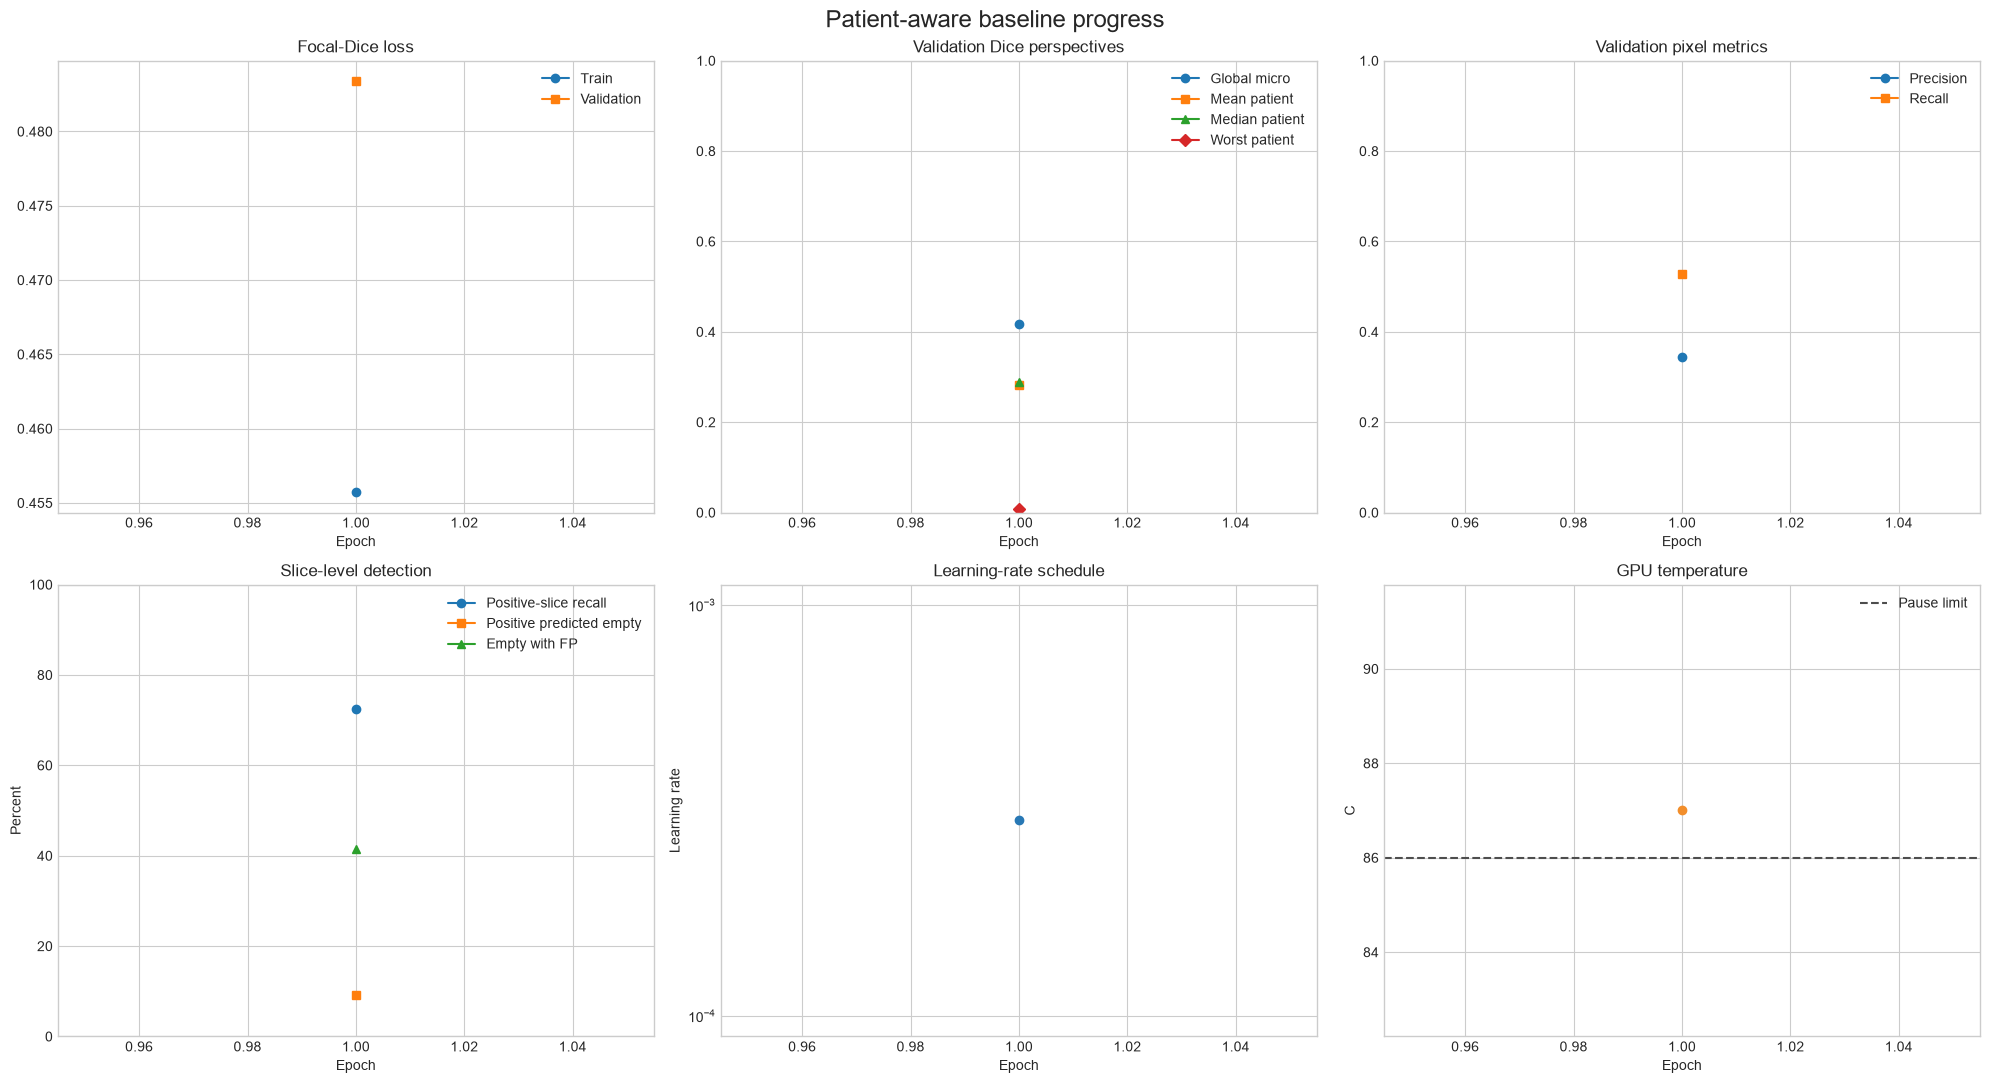

In [8]:
if history_frame.empty:
    print("No history available yet.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    axes[0, 0].plot(history_frame["epoch"], history_frame["train_loss"], marker="o", label="Train")
    axes[0, 0].plot(history_frame["epoch"], history_frame["val_loss"], marker="s", label="Validation")
    axes[0, 0].set_title("Focal-Dice loss"); axes[0, 0].set_xlabel("Epoch"); axes[0, 0].legend()

    for metric, label, marker in [
        ("val_global_micro_dice", "Global micro", "o"),
        ("val_mean_patient_dice", "Mean patient", "s"),
        ("val_median_patient_dice", "Median patient", "^"),
        ("val_worst_patient_dice", "Worst patient", "D"),
    ]:
        axes[0, 1].plot(history_frame["epoch"], history_frame[metric], marker=marker, label=label)
    axes[0, 1].set_ylim(0, 1); axes[0, 1].set_title("Validation Dice perspectives")
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].legend()

    axes[0, 2].plot(history_frame["epoch"], history_frame["val_pixel_precision"], marker="o", label="Precision")
    axes[0, 2].plot(history_frame["epoch"], history_frame["val_pixel_recall"], marker="s", label="Recall")
    axes[0, 2].set_ylim(0, 1); axes[0, 2].set_title("Validation pixel metrics")
    axes[0, 2].set_xlabel("Epoch"); axes[0, 2].legend()

    axes[1, 0].plot(history_frame["epoch"], 100 * history_frame["val_positive_slice_recall"], marker="o", label="Positive-slice recall")
    axes[1, 0].plot(history_frame["epoch"], history_frame["val_positive_predicted_empty_pct"], marker="s", label="Positive predicted empty")
    axes[1, 0].plot(history_frame["epoch"], history_frame["val_empty_slice_false_positive_pct"], marker="^", label="Empty with FP")
    axes[1, 0].set_ylim(0, 100); axes[1, 0].set_title("Slice-level detection")
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Percent"); axes[1, 0].legend()

    axes[1, 1].plot(history_frame["epoch"], history_frame["lr"], marker="o", color="#2878B5")
    axes[1, 1].set_yscale("log"); axes[1, 1].set_title("Learning-rate schedule")
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Learning rate")

    axes[1, 2].plot(history_frame["epoch"], history_frame["temperature_c"], marker="o", color="#F28E2B")
    axes[1, 2].axhline(MAX_GPU_TEMP_C, linestyle="--", color="#4D4D4D", label="Pause limit")
    axes[1, 2].set_title("GPU temperature"); axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("C"); axes[1, 2].legend()

    fig.suptitle("Patient-aware baseline progress", fontsize=17)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "patient_aware_progress.png", dpi=160, bbox_inches="tight")
    plt.show()

### 8. Plot patient Dice trajectories and checkpoint-selection heatmap

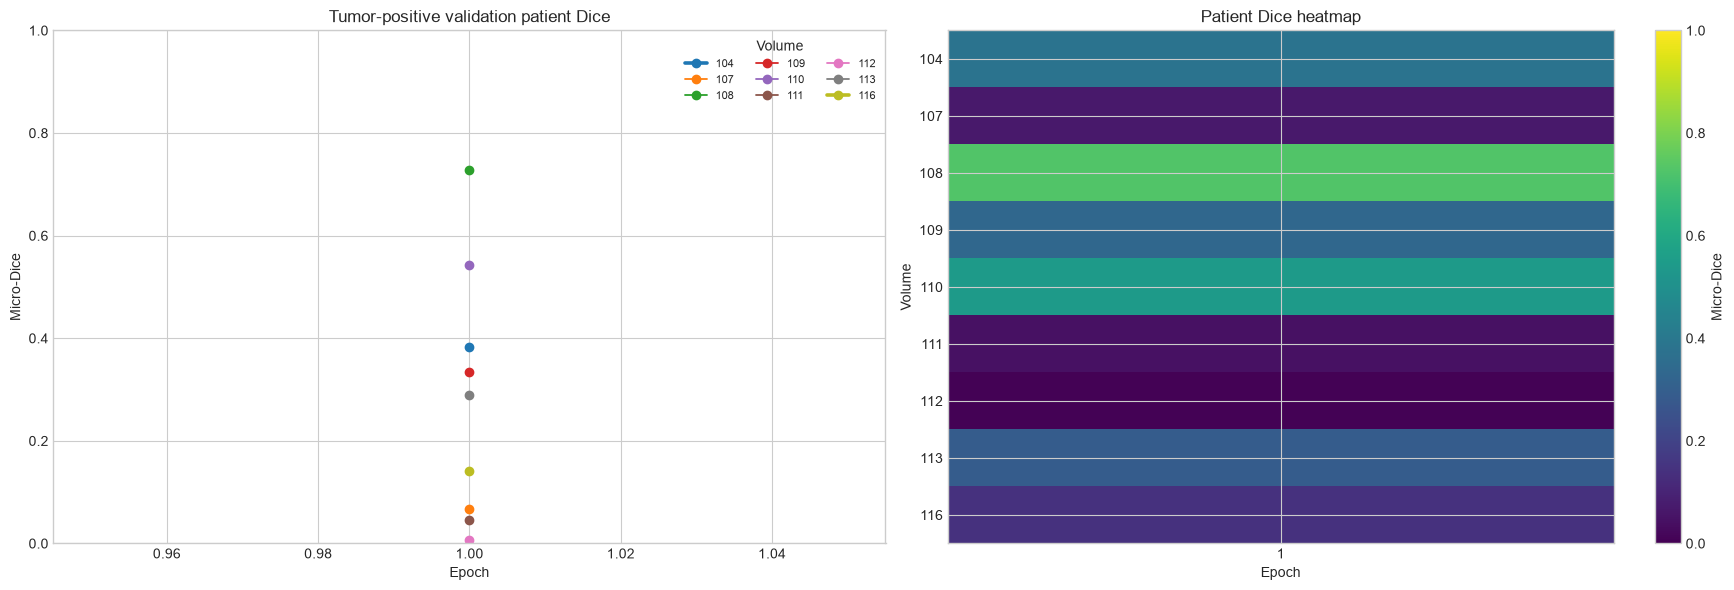

In [9]:
if patient_history_frame.empty:
    print("Patient history is unavailable.")
else:
    positive_patient_history = patient_history_frame.loc[
        patient_history_frame["true_pixels"].gt(0)
    ].copy()
    matrix = positive_patient_history.pivot(
        index="volume_id", columns="epoch", values="micro_dice"
    ).sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    for volume_id, group in positive_patient_history.groupby("volume_id"):
        linewidth = 2.6 if volume_id in {104, 116} else 1.3
        axes[0].plot(group["epoch"], group["micro_dice"], marker="o", linewidth=linewidth, label=str(volume_id))
    axes[0].set_ylim(0, 1); axes[0].set_title("Tumor-positive validation patient Dice")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Micro-Dice")
    axes[0].legend(title="Volume", ncol=3, fontsize=8)

    image = axes[1].imshow(matrix.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
    axes[1].set_title("Patient Dice heatmap")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Volume")
    axes[1].set_xticks(range(len(matrix.columns)), matrix.columns)
    axes[1].set_yticks(range(len(matrix.index)), matrix.index)
    fig.colorbar(image, ax=axes[1], label="Micro-Dice")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "patient_dice_trajectories.png", dpi=160, bbox_inches="tight")
    plt.show()

### 9. Evaluate the best checkpoint, size quartiles, and threshold sensitivity

,value
best_epoch,1.000000e+00
loss,4.833848e-01
global_micro_dice,4.174353e-01
pixel_precision,3.451628e-01
pixel_recall,5.279892e-01
positive_slice_recall,7.236084e-01
positive_predicted_empty_pct,9.117083e+00
empty_slice_false_positive_pct,4.139791e+01
mean_patient_dice,2.821161e-01
median_patient_dice,2.898975e-01


,volume_id,micro_dice,true_pixels,predicted_pixels,positive_slices,positive_slice_recall,positive_predicted_empty_pct,empty_slice_false_positive_pct
0,104,3.826136e-01,69032,29574,122,0.491803,18.852459,28.224583
1,105,9.782056e-12,0,102228,0,0.000000,0.000000,52.636917
2,106,4.945843e-11,0,20219,0,0.000000,0.000000,47.600519
3,107,6.755010e-02,1473,17091,71,0.450704,38.028169,30.857143
4,108,7.276937e-01,363698,379612,202,0.920792,0.495050,30.581040
5,109,3.340622e-01,18200,36682,131,0.847328,7.633588,34.720000
6,110,5.433121e-01,31120,29048,130,0.815385,10.769231,34.402332
7,111,4.509638e-02,1830,47664,92,0.641304,10.869565,41.704036
8,112,7.642833e-03,295,47593,26,0.692308,0.000000,59.448276
9,113,2.898975e-01,21076,67645,135,0.874074,4.444444,40.798859


,size_quartile,slices,mean_dice,median_dice,detected_pct,predicted_empty_pct
0,Q1 smallest,263,0.194471,9.999990e-07,49.049430,23.193916
1,Q2,258,0.340239,3.310272e-01,72.868217,7.364341
2,Q3,260,0.453824,5.606588e-01,78.846154,5.000000
3,Q4 largest,261,0.541999,7.208855e-01,88.888889,0.766284


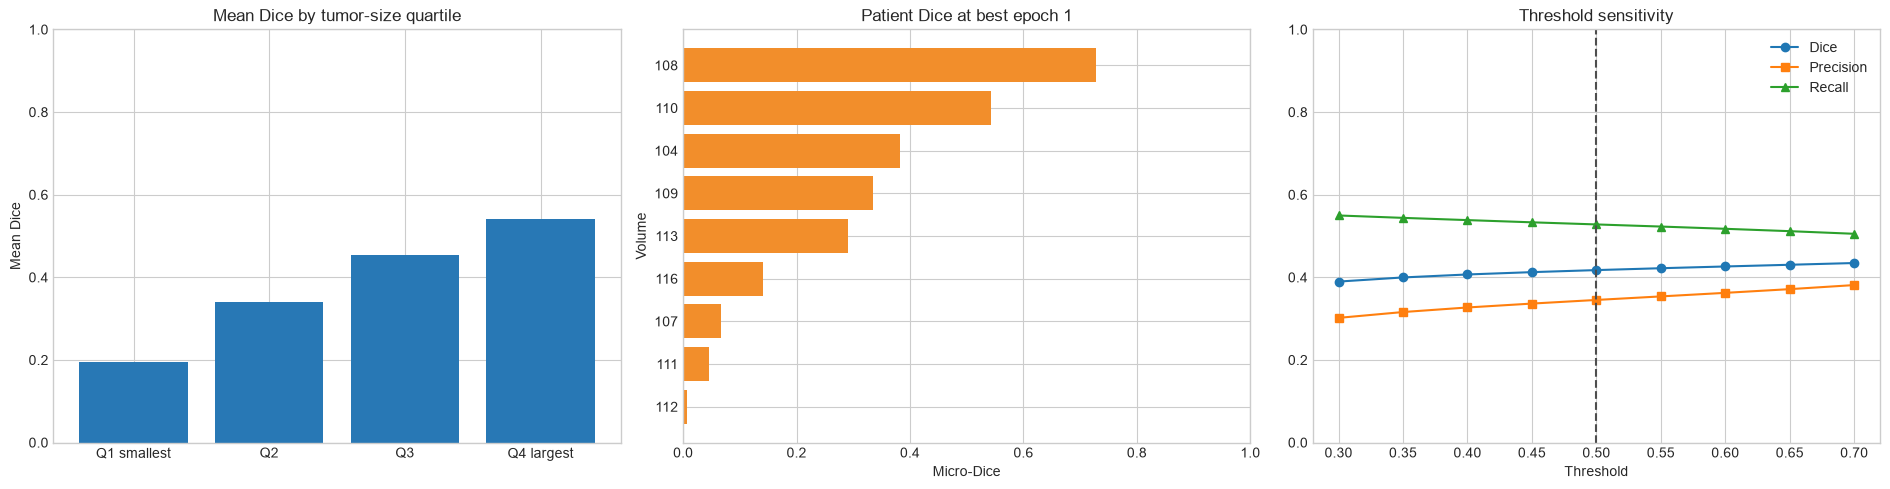

In [10]:
best_per_slice = pd.DataFrame()
best_patient_metrics = pd.DataFrame()
threshold_table = pd.DataFrame()

if best_checkpoint.is_file():
    best_payload = torch.load(best_checkpoint, map_location=device, weights_only=False)
    model.load_state_dict(best_payload["model_state"])
    best_epoch = int(best_payload["epoch"])
    final_result = evaluate_patient_aware(
        model, val_loader, criterion, device, FIXED_THRESHOLD, collect_rows=True
    )
    best_per_slice = pd.DataFrame(final_result.pop("rows"))
    best_patient_metrics = pd.DataFrame(final_result.pop("patient_rows"))
    best_per_slice.to_csv(OUTPUT_DIR / "best_validation_per_slice.csv", index=False)
    best_patient_metrics.to_csv(OUTPUT_DIR / "best_validation_patient_metrics.csv", index=False)

    positive_rows = best_per_slice.loc[best_per_slice["true_pixels"].gt(0)].copy()
    positive_rows["size_quartile"] = pd.qcut(
        positive_rows["true_pixels"], q=4,
        labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"],
        duplicates="drop",
    )
    size_metrics = (
        positive_rows.groupby("size_quartile", observed=True)
        .agg(
            slices=("sample_id", "size"), mean_dice=("dice", "mean"),
            median_dice=("dice", "median"),
            detected_pct=("intersection_pixels", lambda x: 100 * (x > 0).mean()),
            predicted_empty_pct=("predicted_pixels", lambda x: 100 * (x == 0).mean()),
        )
        .reset_index()
    )
    size_metrics.to_csv(OUTPUT_DIR / "best_validation_size_quartiles.csv", index=False)
    display(pd.DataFrame([{"best_epoch": best_epoch, **final_result}]).T.rename(columns={0: "value"}))
    display(best_patient_metrics)
    display(size_metrics)

    accumulators = {
        float(t): {"intersection": 0, "predicted": 0, "actual": 0} for t in THRESHOLDS
    }
    model.eval()
    with torch.inference_mode():
        for batch in val_loader:
            images = batch["image"].to(device, non_blocking=True)
            truth = batch["mask"].to(device, non_blocking=True) >= 0.5
            probabilities = torch.sigmoid(model(images))
            for threshold, acc in accumulators.items():
                prediction = probabilities >= threshold
                acc["intersection"] += int((prediction & truth).sum())
                acc["predicted"] += int(prediction.sum())
                acc["actual"] += int(truth.sum())
    threshold_table = pd.DataFrame([
        {
            "threshold": threshold,
            "micro_dice": (2 * acc["intersection"] + 1e-6) / (acc["predicted"] + acc["actual"] + 1e-6),
            "precision": (acc["intersection"] + 1e-6) / (acc["predicted"] + 1e-6),
            "recall": (acc["intersection"] + 1e-6) / (acc["actual"] + 1e-6),
        }
        for threshold, acc in accumulators.items()
    ])
    threshold_table.to_csv(OUTPUT_DIR / "best_validation_threshold_sweep.csv", index=False)

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    axes[0].bar(size_metrics["size_quartile"].astype(str), size_metrics["mean_dice"], color="#2878B5")
    axes[0].set_ylim(0, 1); axes[0].set_title("Mean Dice by tumor-size quartile")
    axes[0].set_xlabel(""); axes[0].set_ylabel("Mean Dice")

    positive_patients = best_patient_metrics.loc[best_patient_metrics["true_pixels"].gt(0)].sort_values("micro_dice")
    axes[1].barh(positive_patients["volume_id"].astype(str), positive_patients["micro_dice"], color="#F28E2B")
    axes[1].set_xlim(0, 1); axes[1].set_title(f"Patient Dice at best epoch {best_epoch}")
    axes[1].set_xlabel("Micro-Dice"); axes[1].set_ylabel("Volume")

    axes[2].plot(threshold_table["threshold"], threshold_table["micro_dice"], marker="o", label="Dice")
    axes[2].plot(threshold_table["threshold"], threshold_table["precision"], marker="s", label="Precision")
    axes[2].plot(threshold_table["threshold"], threshold_table["recall"], marker="^", label="Recall")
    axes[2].axvline(FIXED_THRESHOLD, linestyle="--", color="#4D4D4D")
    axes[2].set_ylim(0, 1); axes[2].set_title("Threshold sensitivity")
    axes[2].set_xlabel("Threshold"); axes[2].legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "best_model_diagnostics.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Best checkpoint unavailable; run training first.")

### 10. Visualize worst, best, and key-patient predictions

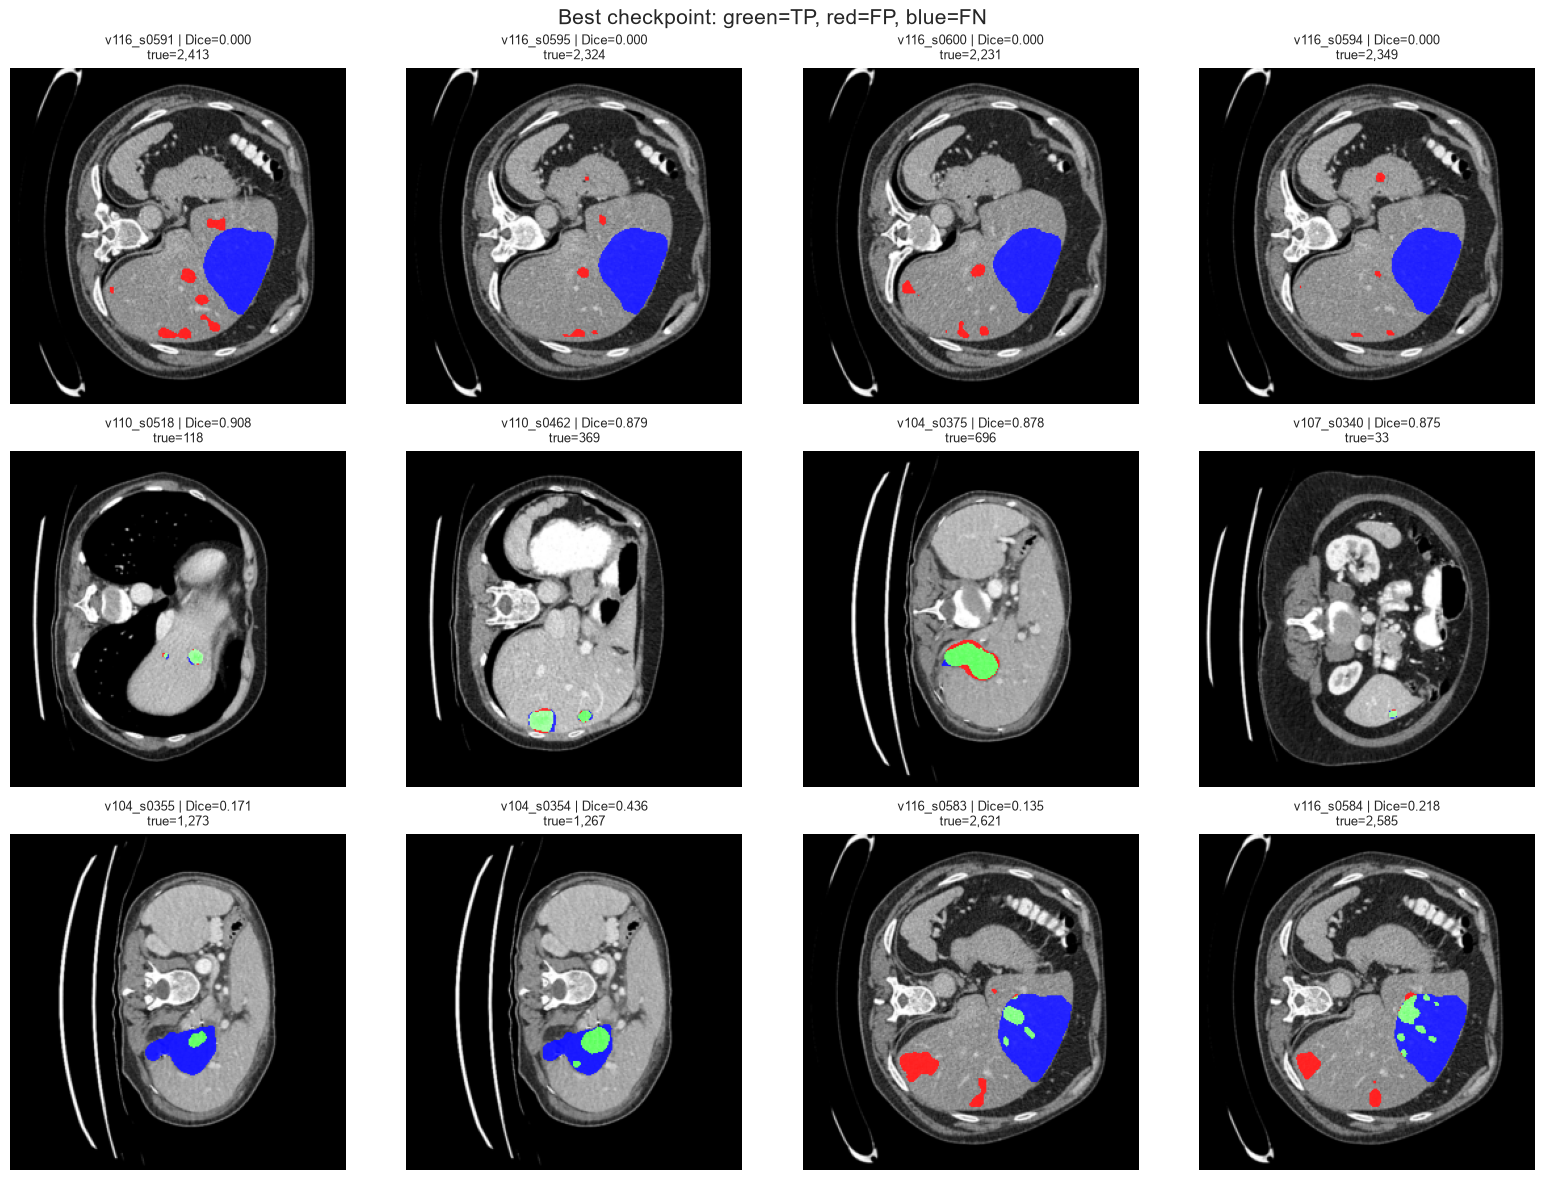

In [11]:
if not best_per_slice.empty:
    positive_rows = best_per_slice.loc[best_per_slice["true_pixels"].gt(0)]
    review_ids = []
    review_ids += positive_rows.nsmallest(4, "dice")["sample_id"].tolist()
    review_ids += positive_rows.nlargest(4, "dice")["sample_id"].tolist()
    for volume_id in [104, 116]:
        candidates = positive_rows.loc[positive_rows["volume_id"].eq(volume_id)]
        if len(candidates):
            review_ids += candidates.nlargest(2, "true_pixels")["sample_id"].tolist()
    review_ids = list(dict.fromkeys(review_ids))[:12]

    review_dataset = VerifiedManifestDataset(
        MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
        target="tumor", sample_ids=review_ids,
    )
    review_loader = DataLoader(review_dataset, batch_size=4, shuffle=False, num_workers=0)
    probabilities_by_id = {}
    model.eval()
    with torch.inference_mode():
        for batch in review_loader:
            probabilities = torch.sigmoid(model(batch["image"].to(device))).cpu().numpy()
            for index, sample_id in enumerate(batch["sample_id"]):
                probabilities_by_id[sample_id] = probabilities[index, 0]

    rows_count = math.ceil(len(review_dataset) / 4)
    fig, axes = plt.subplots(rows_count, 4, figsize=(16, 4 * rows_count))
    axes = np.atleast_1d(axes).ravel()
    for axis, item in zip(axes, review_dataset):
        sample_id = item["sample_id"]
        image = item["image"][0].numpy()
        truth = item["mask"][0].numpy().astype(bool)
        prediction = probabilities_by_id[sample_id] >= FIXED_THRESHOLD
        tp, fp, fn = prediction & truth, prediction & ~truth, truth & ~prediction
        rgb = np.repeat(image[..., None], 3, axis=2)
        rgb[tp, 1] = 1.0
        rgb[fp, 0] = 1.0; rgb[fp, 1:] *= 0.25
        rgb[fn, 2] = 1.0; rgb[fn, :2] *= 0.25
        row = best_per_slice.loc[best_per_slice["sample_id"].eq(sample_id)].iloc[0]
        axis.imshow(rgb)
        axis.set_title(f"{sample_id} | Dice={row['dice']:.3f}\ntrue={row['true_pixels']:,}", fontsize=9)
        axis.axis("off")
    for axis in axes[len(review_dataset):]:
        axis.axis("off")
    fig.suptitle("Best checkpoint: green=TP, red=FP, blue=FN", fontsize=15)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "best_model_prediction_errors.png", dpi=160, bbox_inches="tight")
    plt.show()

## Takeaways

### 11. Produce the final continuation gate

In [12]:
if history_frame.empty or best_patient_metrics.empty:
    final_gate = {
        "status": "not_run",
        "test_images_accessed": False,
        "decision": "Run or resume training before making a continuation decision.",
    }
else:
    best_history_row = history_frame.loc[history_frame["val_mean_patient_dice"].idxmax()]
    tumor_positive_patients = best_patient_metrics.loc[best_patient_metrics["true_pixels"].gt(0)]
    volume_104 = tumor_positive_patients.loc[tumor_positive_patients["volume_id"].eq(104), "micro_dice"]
    volume_116 = tumor_positive_patients.loc[tumor_positive_patients["volume_id"].eq(116), "micro_dice"]

    smoke_patient_mean = None
    if SMOKE_PER_SLICE.is_file():
        smoke = pd.read_csv(SMOKE_PER_SLICE)
        smoke_positive = smoke.loc[smoke["true_pixels"].gt(0)]
        smoke_patient = smoke_positive.groupby("volume_id").agg(
            intersection=("intersection_pixels", "sum"),
            predicted=("predicted_pixels", "sum"),
            true=("true_pixels", "sum"),
        )
        smoke_patient["dice"] = (
            2 * smoke_patient["intersection"] / (smoke_patient["predicted"] + smoke_patient["true"])
        )
        smoke_patient_mean = float(smoke_patient["dice"].mean())

    patient_improved = (
        smoke_patient_mean is None
        or float(best_history_row["val_mean_patient_dice"]) > smoke_patient_mean
    )
    key_patients_nonzero = bool(
        len(volume_104) and len(volume_116)
        and float(volume_104.iloc[0]) > 0.05
        and float(volume_116.iloc[0]) > 0.05
    )
    detection_acceptable = bool(
        float(best_history_row["val_positive_predicted_empty_pct"]) < 25
        and float(best_history_row["val_empty_slice_false_positive_pct"]) < 15
    )
    ready = patient_improved and key_patients_nonzero and detection_acceptable

    final_gate = {
        "status": "ready_for_next_stage" if ready else "needs_model_revision",
        "manifest_sha256": manifest_hash,
        "epochs_completed": int(history_frame["epoch"].max()),
        "best_epoch": int(best_history_row["epoch"]),
        "best_global_micro_dice": float(best_history_row["val_global_micro_dice"]),
        "best_mean_patient_dice": float(best_history_row["val_mean_patient_dice"]),
        "best_median_patient_dice": float(best_history_row["val_median_patient_dice"]),
        "best_worst_patient_dice": float(best_history_row["val_worst_patient_dice"]),
        "smoke_mean_patient_dice": smoke_patient_mean,
        "volume_104_dice": float(volume_104.iloc[0]) if len(volume_104) else None,
        "volume_116_dice": float(volume_116.iloc[0]) if len(volume_116) else None,
        "patient_mean_improved": patient_improved,
        "key_patients_above_0_05": key_patients_nonzero,
        "detection_guardrails_pass": detection_acceptable,
        "test_images_accessed": False,
        "decision": (
            "PASS — freeze the baseline protocol and plan the next model comparison."
            if ready else
            "STOP — inspect patient trajectories, size strata, and errors before changing architecture or loss."
        ),
    }

(OUTPUT_DIR / "patient_aware_gate_result.json").write_text(
    json.dumps(final_gate, indent=2), encoding="utf-8"
)
display(pd.DataFrame([final_gate]).T.rename(columns={0: "result"}))
print(final_gate["decision"])

,result
status,needs_model_revision
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
epochs_completed,1
best_epoch,1
best_global_micro_dice,0.417435
best_mean_patient_dice,0.282116
best_median_patient_dice,0.289898
best_worst_patient_dice,0.007643
smoke_mean_patient_dice,0.348891
volume_104_dice,0.382614


STOP — inspect patient trajectories, size strata, and errors before changing architecture or loss.


### Interpretation guide

- If patient mean improves and volumes 104/116 become nonzero, the longer
  baseline has addressed the main smoke-test failure.
- If global Dice rises while patient mean remains flat, the model is still
  dominated by high-burden patients.
- If volume 116 remains near zero after 10–15 epochs, stop and consider a
  liver-first or multitask liver/tumor strategy.
- If false positives rise, reduce positive sampling or strengthen negative
  exposure before changing the decision threshold.
- Threshold curves are diagnostic only. Do not touch the test split until the
  architecture, stopping rule, sampling, loss, and threshold-selection
  procedure are frozen.